# UTS Computer Vision – Ekstraksi Fitur (SIFT & ORB)
Kelompok: 12 | Dataset: LOL Dataset (Kaggle)

# 1. Inisiasi Dataset

In [ ]:
import os, glob, random, time, shutil
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

SEED = 12
N_IMAGES = 25
IMG_SIZE = (600, 400)

random.seed(SEED)
np.random.seed(SEED)

dataset_path = kagglehub.dataset_download("soumikrakshit/lol-dataset")
print("Dataset ada di:", dataset_path)

Using Colab cache for faster access to the 'lol-dataset' dataset.
Dataset ada di: /kaggle/input/lol-dataset


In [ ]:
all_low = sorted(glob.glob(os.path.join(dataset_path, "**", "our485", "low", "*.png"), recursive=True))
print("Total citra low-light:", len(all_low))

random.seed(SEED)
subset = random.sample(all_low, N_IMAGES)

paths = subset
names = [os.path.basename(p) for p in paths]
images = [cv2.resize(cv2.imread(p), IMG_SIZE, interpolation=cv2.INTER_AREA) for p in paths]

print("Jumlah citra :", len(images))
print("Shape        :", images[0].shape)
print("Dtype        :", images[0].dtype)
print("Contoh nama  :", names[:3])

Total citra low-light: 485
Jumlah citra : 25
Shape        : (400, 600, 3)
Dtype        : uint8
Contoh nama  : ['551.png', '261.png', '649.png']


## Section 2 – Grayscale & Enhancement (Ahmad)

In [ ]:
# 1. Konversi Semua Citra ke Grayscale
gray_images = [cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) for img in images]

print("Jumlah citra grayscale:", len(gray_images))
print("Shape citra grayscale :", gray_images[0].shape)

Jumlah citra grayscale: 25
Shape citra grayscale : (400, 600)


In [ ]:
# 2. Implementasi 3 Metode Enhancement

# A. Histogram Equalization (HE)
he_images = [cv2.equalizeHist(gray) for gray in gray_images]

# B. Contrast Stretching
def contrast_stretching(img):
    # Formula: (I - Min) * (255 / (Max - Min))
    min_val = np.min(img)
    max_val = np.max(img)
    if max_val - min_val == 0:
        return img.copy()
    stretched = (img - min_val) * (255.0 / (max_val - min_val))
    return stretched.astype(np.uint8)

cs_images = [contrast_stretching(gray) for gray in gray_images]

# C. CLAHE (Contrast Limited Adaptive Histogram Equalization)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
clahe_images = [clahe.apply(gray) for gray in gray_images]

print("Proses Grayscale dan ketiga metode Enhancement telah selesai dilakukan untuk seluruh citra.")

Proses Grayscale dan ketiga metode Enhancement telah selesai dilakukan untuk seluruh citra.


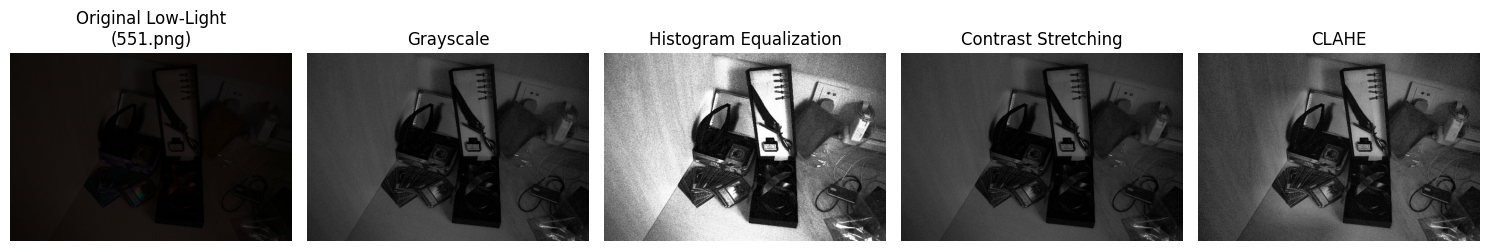

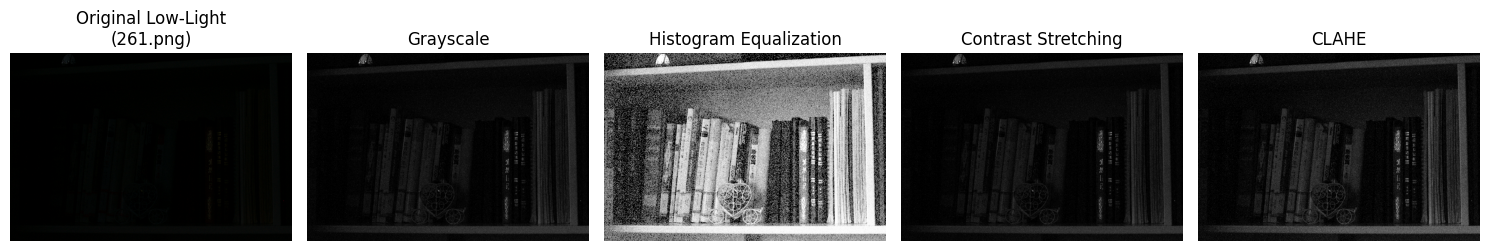

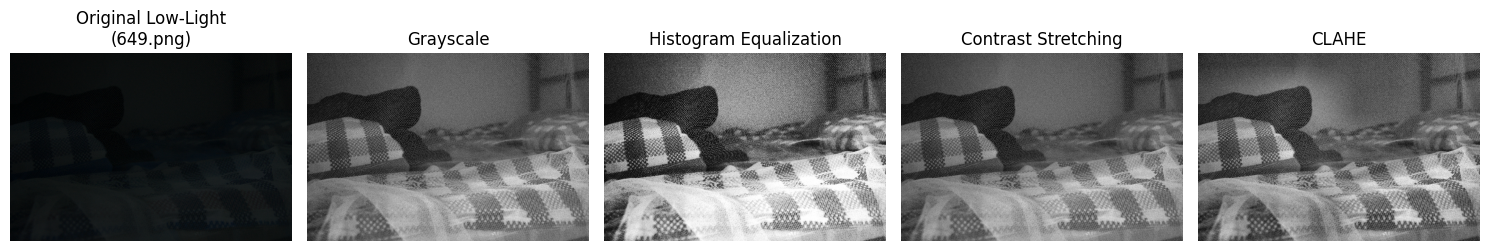

In [ ]:
# 3. Visualisasi Hasil Perbandingan (Sampel 3 Gambar)
sample_indices = [0, 1, 2] # Mengambil 3 sampel citra pertama

for idx in sample_indices:
    plt.figure(figsize=(15, 10))

    # 1. Original (RGB)
    plt.subplot(1, 5, 1)
    plt.imshow(cv2.cvtColor(images[idx], cv2.COLOR_BGR2RGB))
    plt.title(f"Original Low-Light\n({names[idx]})")
    plt.axis('off')

    # 2. Grayscale
    plt.subplot(1, 5, 2)
    plt.imshow(gray_images[idx], cmap='gray')
    plt.title("Grayscale")
    plt.axis('off')

    # 3. Histogram Equalization
    plt.subplot(1, 5, 3)
    plt.imshow(he_images[idx], cmap='gray')
    plt.title("Histogram Equalization")
    plt.axis('off')

    # 4. Contrast Stretching
    plt.subplot(1, 5, 4)
    plt.imshow(cs_images[idx], cmap='gray')
    plt.title("Contrast Stretching")
    plt.axis('off')

    # 5. CLAHE
    plt.subplot(1, 5, 5)
    plt.imshow(clahe_images[idx], cmap='gray')
    plt.title("CLAHE")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

## Section 3 – Gaussian Filter, MSE, PSNR (Datok)

In [ ]:
# 3.1 Konfigurasi dan fungsi (sesuai kesepakatan nama fungsi)
FILTER_METHOD = "gaussian"
KSIZE = 3

def apply_filter(img, method="median", ksize=3):
    """Filter citra uint8. method: 'median' atau 'gaussian'. ksize harus ganjil."""
    if ksize % 2 == 0 or ksize < 1:
        raise ValueError("ksize harus bilangan ganjil positif")
    method = method.lower()
    if method == "median":
        out = cv2.medianBlur(img, ksize)
    elif method == "gaussian":
        out = cv2.GaussianBlur(img, (ksize, ksize), 0)  # sigma dihitung otomatis dari ksize
    else:
        raise ValueError("method harus 'median' atau 'gaussian'")
    return out.astype(np.uint8)

def mse(a, b):
    """Mean Squared Error antara dua citra berukuran sama."""
    if a.shape != b.shape:
        raise ValueError(f"Ukuran berbeda: {a.shape} vs {b.shape}")
    diff = a.astype(np.float64) - b.astype(np.float64)
    return float(np.mean(diff ** 2))

def psnr(a, b, max_val=255.0):
    """Peak Signal-to-Noise Ratio (dB). Bernilai inf jika kedua citra identik."""
    err = mse(a, b)
    if err == 0:
        return float("inf")
    return float(10 * np.log10((max_val ** 2) / err))

# Uji cepat: hasil fungsi manual dibandingkan dengan cv2.PSNR
_a = gray_images[0]
_b = apply_filter(_a, FILTER_METHOD, KSIZE)
print(f"Uji  -> MSE = {mse(_a, _b):.4f} | PSNR manual = {psnr(_a, _b):.4f} dB | cv2.PSNR = {cv2.PSNR(_a, _b):.4f} dB")
print(f"Filter dipakai: {FILTER_METHOD}, ksize = {KSIZE}")

Uji  -> MSE = 1.7160 | PSNR manual = 45.7855 dB | cv2.PSNR = 45.7855 dB
Filter dipakai: gaussian, ksize = 3


In [ ]:
# 3.2 Load citra referensi (normal-light) dari folder our485/high, nama file sama
def high_path_from_low(low_path):
    return os.path.join(os.path.dirname(os.path.dirname(low_path)), "high", os.path.basename(low_path))

ref_paths = [high_path_from_low(p) for p in paths]
missing = [p for p in ref_paths if not os.path.exists(p)]
assert not missing, f"Citra referensi tidak ditemukan: {missing[:3]}"

ref_images = [cv2.resize(cv2.imread(p), IMG_SIZE, interpolation=cv2.INTER_AREA) for p in ref_paths]
ref_gray = [cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) for img in ref_images]

print("Jumlah citra referensi:", len(ref_gray))
print("Shape referensi       :", ref_gray[0].shape, "| sama dengan citra uji:", ref_gray[0].shape == gray_images[0].shape)

Jumlah citra referensi: 25
Shape referensi       : (400, 600) | sama dengan citra uji: True


In [ ]:
# 3.3 Terapkan filter ke semua citra hasil Section 2
enhanced_images = {
    "Grayscale (tanpa enhancement)": gray_images,
    "Histogram Equalization": he_images,
    "Contrast Stretching": cs_images,
    "CLAHE": clahe_images,
}

filtered_images = {
    name: [apply_filter(img, FILTER_METHOD, KSIZE) for img in imgs]
    for name, imgs in enhanced_images.items()
}

print(f"Filter {FILTER_METHOD} (ksize={KSIZE}) diterapkan ke {len(filtered_images)} kelompok citra x {len(gray_images)} citra.")

Filter gaussian (ksize=3) diterapkan ke 4 kelompok citra x 25 citra.


In [ ]:
# 3.4 Hitung MSE dan PSNR per citra (sebelum dan sesudah filter), terhadap referensi
rows = []
for method_name in enhanced_images:
    for i in range(len(names)):
        before = enhanced_images[method_name][i]
        after = filtered_images[method_name][i]
        ref = ref_gray[i]
        rows.append({
            "citra": names[i],
            "metode": method_name,
            "MSE_sebelum_filter": mse(before, ref),
            "PSNR_sebelum_filter": psnr(before, ref),
            "MSE_sesudah_filter": mse(after, ref),
            "PSNR_sesudah_filter": psnr(after, ref),
        })

df_metrics = pd.DataFrame(rows)

print("Contoh hasil per citra (5 baris pertama):")
display(df_metrics.head().round(2))

Contoh hasil per citra (5 baris pertama):


,citra,metode,MSE_sebelum_filter,PSNR_sebelum_filter,MSE_sesudah_filter,PSNR_sesudah_filter
0,551.png,Grayscale (tanpa enhancement),16925.16,5.85,16927.70,5.84
1,261.png,Grayscale (tanpa enhancement),16357.68,5.99,16361.44,5.99
2,649.png,Grayscale (tanpa enhancement),15219.92,6.31,15201.51,6.31
3,578.png,Grayscale (tanpa enhancement),9012.34,8.58,9009.04,8.58
4,655.png,Grayscale (tanpa enhancement),14155.98,6.62,14153.76,6.62


In [ ]:
# 3.5 Tabel rata-rata MSE dan PSNR per metode
order = list(enhanced_images.keys())
avg_table = (df_metrics.drop(columns="citra")
             .groupby("metode", sort=False).mean()
             .reindex(order))
avg_table["Selisih_PSNR (dB)"] = avg_table["PSNR_sesudah_filter"] - avg_table["PSNR_sebelum_filter"]
avg_table = avg_table.round(2)
avg_table.index.name = f"Metode (filter {FILTER_METHOD}, k={KSIZE}, n={len(names)})"

print(f"TABEL RATA-RATA MSE & PSNR terhadap citra referensi normal-light ({len(names)} citra)")
display(avg_table)

best = avg_table["PSNR_sesudah_filter"].idxmax()
print(f"PSNR rata-rata tertinggi setelah filter: {best} ({avg_table.loc[best, 'PSNR_sesudah_filter']:.2f} dB)")

TABEL RATA-RATA MSE & PSNR terhadap citra referensi normal-light (25 citra)


,MSE_sebelum_filter,PSNR_sebelum_filter,MSE_sesudah_filter,PSNR_sesudah_filter,Selisih_PSNR (dB)
"Metode (filter gaussian, k=3, n=25)",,,,,
Grayscale (tanpa enhancement),12594.83,7.62,12598.81,7.62,-0.00
Histogram Equalization,2223.47,15.55,1887.04,16.45,0.89
Contrast Stretching,5816.00,12.58,5789.47,12.71,0.13
CLAHE,9017.82,9.28,9022.39,9.28,-0.00


PSNR rata-rata tertinggi setelah filter: Histogram Equalization (16.45 dB)


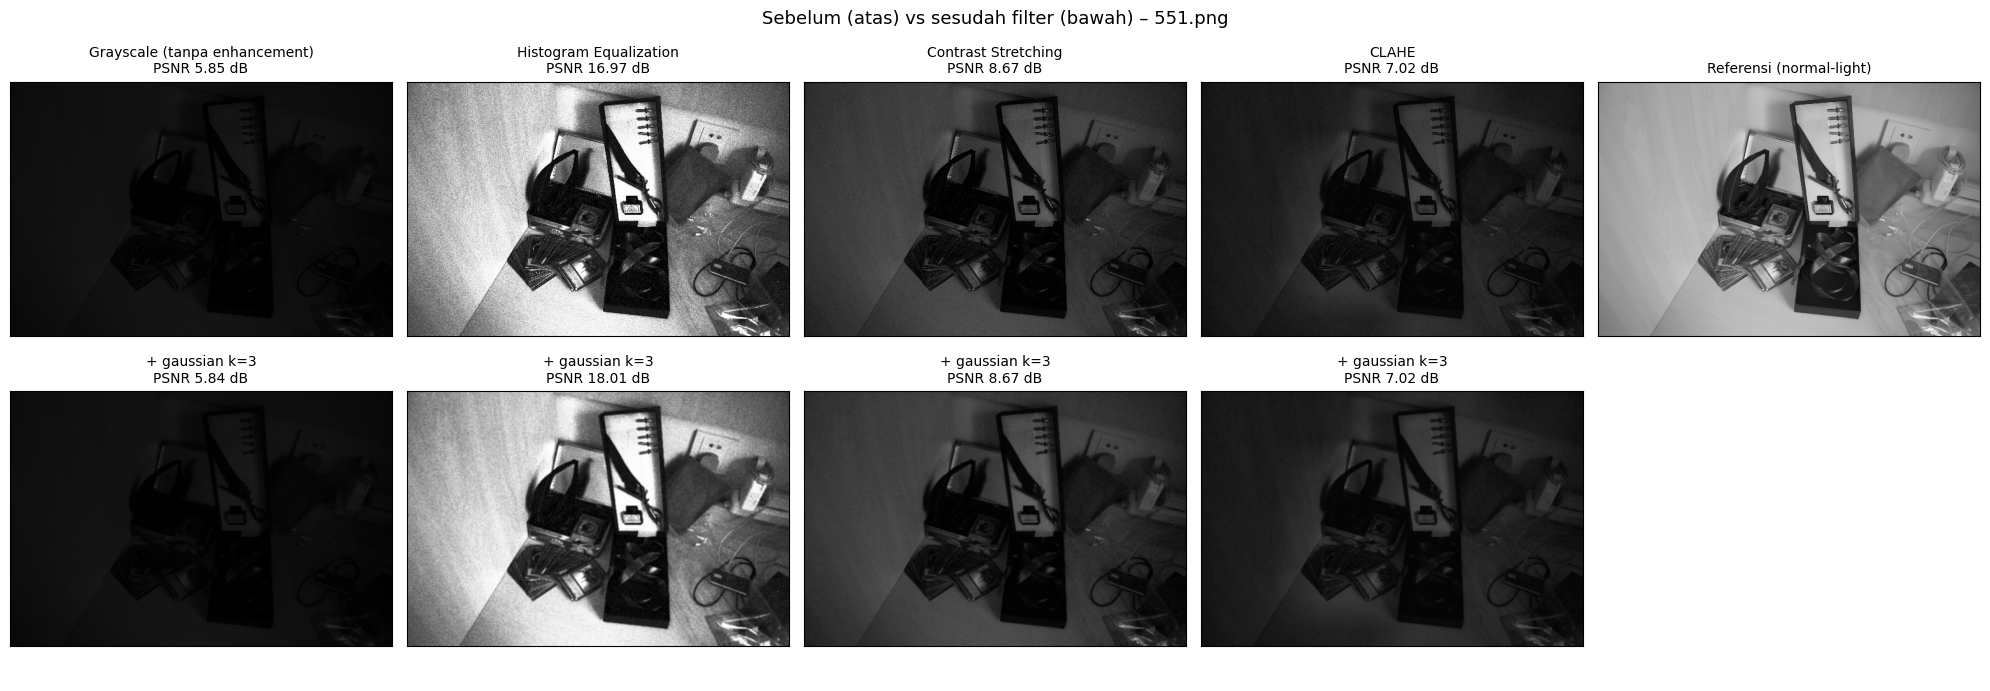

In [ ]:
# 3.6 Visualisasi: sebelum vs sesudah filter (sampel citra pertama) + referensi
idx = 0
fig, axes = plt.subplots(2, 5, figsize=(20, 7))

for col, method_name in enumerate(order):
    before = enhanced_images[method_name][idx]
    after = filtered_images[method_name][idx]
    # vmin/vmax dikunci 0-255 agar matplotlib tidak menormalisasi kecerahan otomatis
    axes[0, col].imshow(before, cmap="gray", vmin=0, vmax=255)
    axes[0, col].set_title(f"{method_name}\nPSNR {psnr(before, ref_gray[idx]):.2f} dB", fontsize=10)
    axes[1, col].imshow(after, cmap="gray", vmin=0, vmax=255)
    axes[1, col].set_title(f"+ {FILTER_METHOD} k={KSIZE}\nPSNR {psnr(after, ref_gray[idx]):.2f} dB", fontsize=10)

axes[0, 4].imshow(ref_gray[idx], cmap="gray", vmin=0, vmax=255)
axes[0, 4].set_title("Referensi (normal-light)", fontsize=10)
axes[1, 4].axis("off")
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle(f"Sebelum (atas) vs sesudah filter (bawah) – {names[idx]}", fontsize=13)
plt.tight_layout()
plt.show()

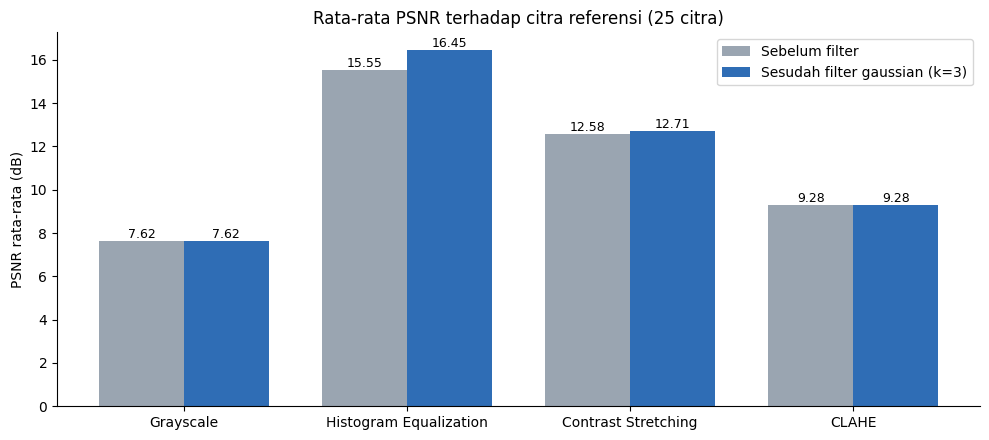

In [ ]:
# 3.7 Grafik rata-rata PSNR per metode
x = np.arange(len(order))
w = 0.38
fig, ax = plt.subplots(figsize=(10, 4.5))
b1 = ax.bar(x - w/2, avg_table["PSNR_sebelum_filter"], w, label="Sebelum filter", color="#9aa5b1")
b2 = ax.bar(x + w/2, avg_table["PSNR_sesudah_filter"], w, label=f"Sesudah filter {FILTER_METHOD} (k={KSIZE})", color="#2f6db5")
ax.bar_label(b1, fmt="%.2f", fontsize=9)
ax.bar_label(b2, fmt="%.2f", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([m.replace(" (tanpa enhancement)", "") for m in order])
ax.set_ylabel("PSNR rata-rata (dB)")
ax.set_title(f"Rata-rata PSNR terhadap citra referensi ({len(names)} citra)")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
# 3.8 Pengaruh ukuran kernel terhadap PSNR rata-rata
ksize_rows = []
for k in [3, 5, 7]:
    for method_name, imgs in enhanced_images.items():
        vals = [psnr(apply_filter(img, FILTER_METHOD, k), ref) for img, ref in zip(imgs, ref_gray)]
        ksize_rows.append({"metode": method_name, "ksize": k, "PSNR_rata2": np.mean(vals)})

ksize_table = (pd.DataFrame(ksize_rows)
               .pivot(index="metode", columns="ksize", values="PSNR_rata2")
               .reindex(order).round(2))
ksize_table.columns = [f"PSNR k={k} (dB)" for k in ksize_table.columns]
print(f"PSNR rata-rata untuk beberapa ukuran kernel (filter {FILTER_METHOD})")
display(ksize_table)

PSNR rata-rata untuk beberapa ukuran kernel (filter gaussian)


,PSNR k=3 (dB),PSNR k=5 (dB),PSNR k=7 (dB)
metode,,,
Grayscale (tanpa enhancement),7.62,7.62,7.61
Histogram Equalization,16.45,16.53,16.55
Contrast Stretching,12.71,12.71,12.69
CLAHE,9.28,9.27,9.26


## Section 4 – SIFT, ORB, Matching (Dezilva)

In [ ]:
# 4.1 Konfigurasi dan fungsi (sesuai kesepakatan nama fungsi)
ORB_NFEATURES = 5000   # batas maksimum keypoint ORB
RATIO = 0.75           # Lowe's ratio test
ACC_THRESH_PX = 5      # match akurat jika jarak posisi keypoint <= 5 piksel

sift_detector = cv2.SIFT_create()
orb_detector = cv2.ORB_create(nfeatures=ORB_NFEATURES)

def extract_sift(img):
    """Ekstraksi fitur SIFT. Mengembalikan (keypoints, descriptors float32 128-dim)."""
    return sift_detector.detectAndCompute(img, None)

def extract_orb(img):
    """Ekstraksi fitur ORB. Mengembalikan (keypoints, descriptors uint8 32-byte)."""
    return orb_detector.detectAndCompute(img, None)

def match(desc1, desc2, method="sift", ratio=RATIO):
    """Brute-Force kNN matching + Lowe's ratio test. Mengembalikan list match yang lolos."""
    if desc1 is None or desc2 is None or len(desc1) < 2 or len(desc2) < 2:
        return []
    norm = cv2.NORM_L2 if method.lower() == "sift" else cv2.NORM_HAMMING
    bf = cv2.BFMatcher(norm)
    good = []
    for pair in bf.knnMatch(desc1, desc2, k=2):
        if len(pair) == 2 and pair[0].distance < ratio * pair[1].distance:
            good.append(pair[0])
    return good

EXTRACTORS = {"SIFT": extract_sift, "ORB": extract_orb}

def timed_extract(algo, img):
    """Ekstraksi + waktu (ms)."""
    t0 = time.perf_counter()
    kp, des = EXTRACTORS[algo](img)
    return kp, des, (time.perf_counter() - t0) * 1000

# Pemanasan (warm-up) agar pemanggilan pertama tidak membuat waktu bias
for algo in EXTRACTORS:
    EXTRACTORS[algo](gray_images[0])

_test = filtered_images[best][0]   # citra hasil enhancement terbaik (Section 3) + filter
kp_s, des_s = extract_sift(_test)
kp_o, des_o = extract_orb(_test)
print(f"Citra uji: {names[0]} ({best} + filter {FILTER_METHOD})")
print(f"Uji SIFT -> {len(kp_s)} keypoint, descriptor {None if des_s is None else des_s.shape}, dtype {None if des_s is None else des_s.dtype}")
print(f"Uji ORB  -> {len(kp_o)} keypoint, descriptor {None if des_o is None else des_o.shape}, dtype {None if des_o is None else des_o.dtype}")

Citra uji: 551.png (Histogram Equalization + filter gaussian)
Uji SIFT -> 1251 keypoint, descriptor (1251, 128), dtype float32
Uji ORB  -> 3329 keypoint, descriptor (3329, 32), dtype uint8


In [ ]:
# 4.2 Ekstraksi fitur SIFT & ORB untuk semua citra: jumlah keypoint dan waktu
features = {}      # features[(algo, metode, i)] = (kp, des)
ref_features = {}  # ref_features[(algo, i)] = (kp, des)
feat_rows = []

for algo in EXTRACTORS:
    for i, ref in enumerate(ref_gray):
        kp, des, _ = timed_extract(algo, ref)
        ref_features[(algo, i)] = (kp, des)
    for method_name, imgs in filtered_images.items():
        for i, img in enumerate(imgs):
            kp, des, t_ms = timed_extract(algo, img)
            features[(algo, method_name, i)] = (kp, des)
            feat_rows.append({"algoritma": algo, "metode": method_name, "citra": names[i],
                              "jumlah_keypoint": len(kp), "waktu_ekstraksi_ms": t_ms})

df_feat = pd.DataFrame(feat_rows)
print(f"Ekstraksi selesai: {len(df_feat)} baris (2 algoritma x {len(filtered_images)} metode x {len(names)} citra)")
display(df_feat.head().round(2))

Ekstraksi selesai: 200 baris (2 algoritma x 4 metode x 25 citra)


,algoritma,metode,citra,jumlah_keypoint,waktu_ekstraksi_ms
0,SIFT,Grayscale (tanpa enhancement),551.png,0,52.09
1,SIFT,Grayscale (tanpa enhancement),261.png,1,60.05
2,SIFT,Grayscale (tanpa enhancement),649.png,0,43.09
3,SIFT,Grayscale (tanpa enhancement),578.png,0,43.92
4,SIFT,Grayscale (tanpa enhancement),655.png,0,43.42


In [ ]:
# 4.3 Tabel rata-rata jumlah keypoint dan waktu ekstraksi
feat_avg = (df_feat.groupby(["metode", "algoritma"], sort=False)[["jumlah_keypoint", "waktu_ekstraksi_ms"]]
            .mean().unstack("algoritma"))
feat_avg = feat_avg.reindex(order)
feat_avg.columns = [f"{'Keypoint' if c == 'jumlah_keypoint' else 'Waktu (ms)'} {a}" for c, a in feat_avg.columns]
feat_avg = feat_avg[["Keypoint SIFT", "Keypoint ORB", "Waktu (ms) SIFT", "Waktu (ms) ORB"]].round(2)
feat_avg.index.name = f"Metode (n={len(names)} citra)"

print("TABEL RATA-RATA JUMLAH KEYPOINT DAN WAKTU EKSTRAKSI PER CITRA")
display(feat_avg)

TABEL RATA-RATA JUMLAH KEYPOINT DAN WAKTU EKSTRAKSI PER CITRA


,Keypoint SIFT,Keypoint ORB,Waktu (ms) SIFT,Waktu (ms) ORB
Metode (n=25 citra),,,,
Grayscale (tanpa enhancement),7.56,21.08,62.53,2.73
Histogram Equalization,2164.44,3416.20,239.07,16.19
Contrast Stretching,533.04,1072.44,75.16,7.74
CLAHE,179.96,382.88,56.15,4.77


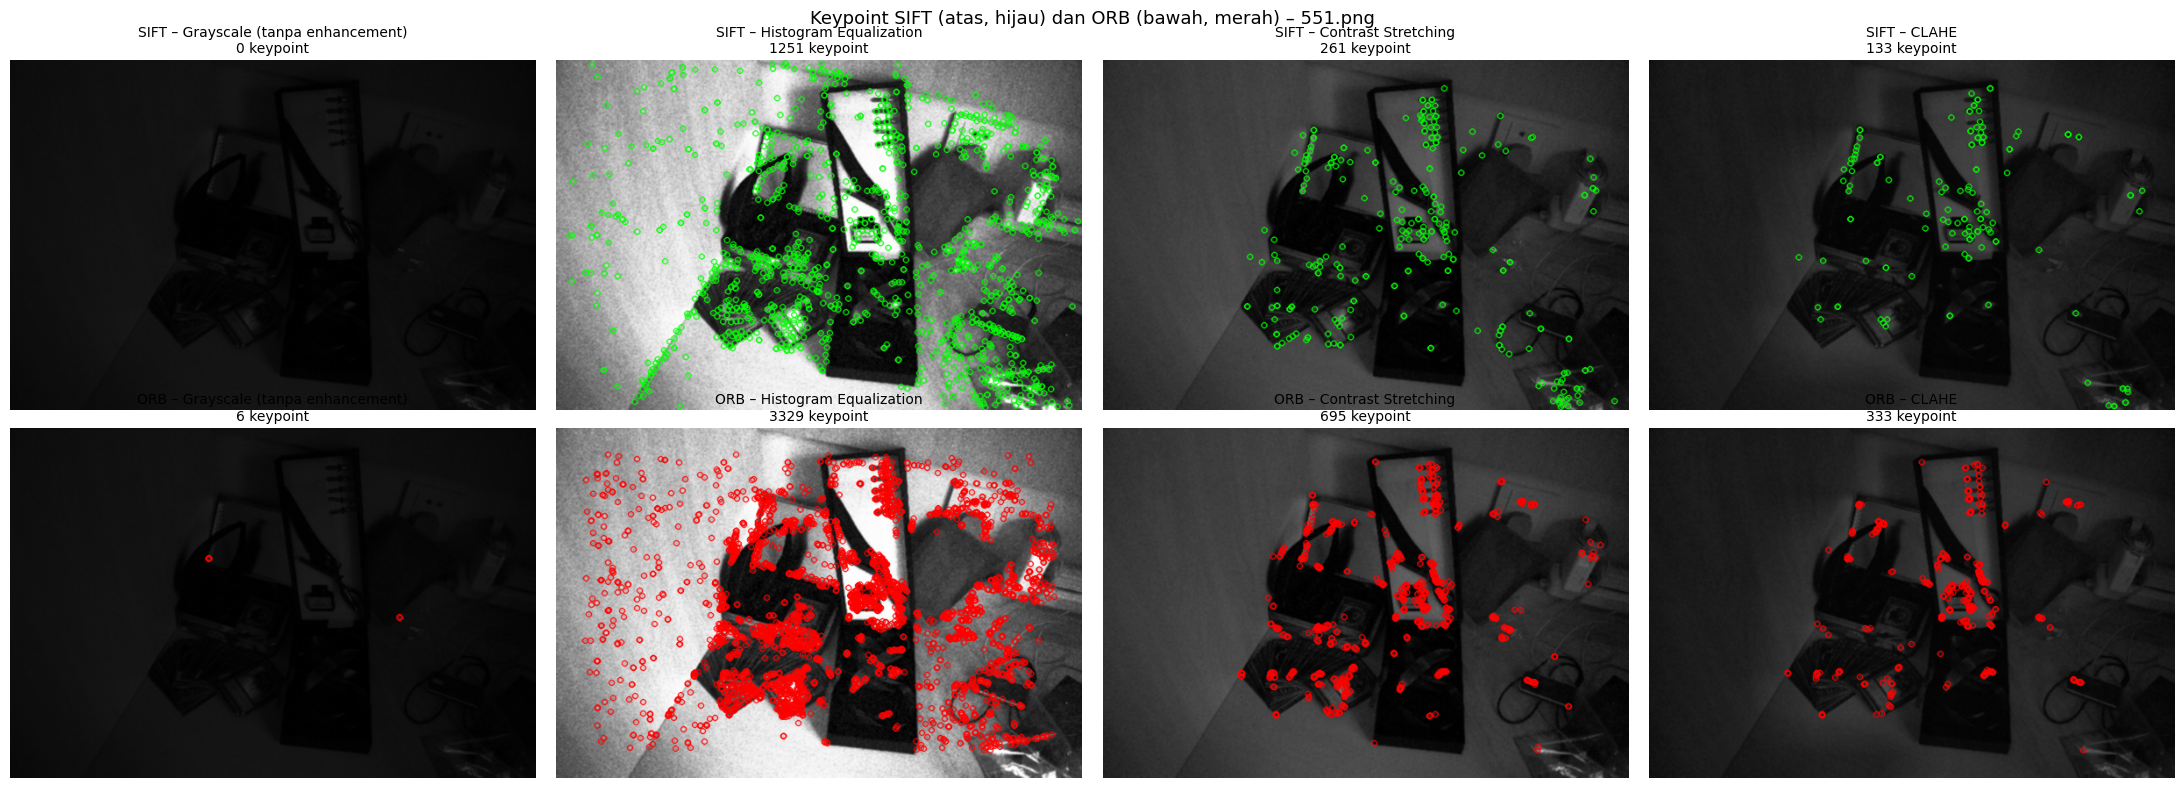

In [ ]:
# 4.4 Visualisasi keypoint SIFT dan ORB (sampel citra pertama)
idx = 0
fig, axes = plt.subplots(2, len(order), figsize=(22, 8))

for col, method_name in enumerate(order):
    img = filtered_images[method_name][idx]
    for row, (algo, color) in enumerate([("SIFT", (0, 255, 0)), ("ORB", (255, 0, 0))]):
        kp, _ = features[(algo, method_name, idx)]
        vis = cv2.drawKeypoints(cv2.cvtColor(img, cv2.COLOR_GRAY2RGB), kp, None, color=color)
        axes[row, col].imshow(vis)
        axes[row, col].set_title(f"{algo} – {method_name}\n{len(kp)} keypoint", fontsize=10)
        axes[row, col].axis("off")

plt.suptitle(f"Keypoint SIFT (atas, hijau) dan ORB (bawah, merah) – {names[idx]}", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# 4.5 Feature matching: citra low-light hasil pemrosesan vs citra referensi normal-light
def match_accuracy(kp1, kp2, matches, thresh=ACC_THRESH_PX):
    """Jumlah match yang posisinya konsisten (pasangan LOL sejajar, jadi posisi seharusnya hampir sama)."""
    if not matches:
        return 0
    p1 = np.float32([kp1[m.queryIdx].pt for m in matches])
    p2 = np.float32([kp2[m.trainIdx].pt for m in matches])
    return int(np.sum(np.linalg.norm(p1 - p2, axis=1) <= thresh))

matches_cache = {}
match_rows = []
for algo in EXTRACTORS:
    for method_name in order:
        for i in range(len(names)):
            kp1, des1 = features[(algo, method_name, i)]
            kp2, des2 = ref_features[(algo, i)]
            t0 = time.perf_counter()
            good = match(des1, des2, algo)
            t_match = (time.perf_counter() - t0) * 1000
            n_acc = match_accuracy(kp1, kp2, good)
            matches_cache[(algo, method_name, i)] = good
            match_rows.append({"algoritma": algo, "metode": method_name, "citra": names[i],
                               "good_matches": len(good), "match_akurat": n_acc,
                               "akurasi_%": 100 * n_acc / len(good) if good else 0.0,
                               "waktu_matching_ms": t_match})

df_match = pd.DataFrame(match_rows)
print(f"Matching selesai: {len(df_match)} pasangan citra")
display(df_match.head().round(2))

Matching selesai: 200 pasangan citra


,algoritma,metode,citra,good_matches,match_akurat,akurasi_%,waktu_matching_ms
0,SIFT,Grayscale (tanpa enhancement),551.png,0,0,0.0,0.0
1,SIFT,Grayscale (tanpa enhancement),261.png,0,0,0.0,0.0
2,SIFT,Grayscale (tanpa enhancement),649.png,0,0,0.0,0.0
3,SIFT,Grayscale (tanpa enhancement),578.png,0,0,0.0,0.0
4,SIFT,Grayscale (tanpa enhancement),655.png,0,0,0.0,0.0


In [ ]:
# 4.6 Tabel rata-rata hasil matching
grp = df_match.groupby(["metode", "algoritma"], sort=False)
match_avg = grp[["good_matches", "match_akurat", "waktu_matching_ms"]].mean()
# Akurasi = total match akurat / total good matches (citra tanpa match tidak dihitung 0%)
match_avg["akurasi_%"] = (100 * grp["match_akurat"].sum() / grp["good_matches"].sum().replace(0, np.nan)).fillna(0)
match_avg = match_avg.unstack("algoritma").reindex(order)
label = {"good_matches": "Good matches", "match_akurat": "Match akurat",
         "akurasi_%": "Akurasi (%)", "waktu_matching_ms": "Waktu matching (ms)"}
match_avg.columns = [f"{label[c]} {a}" for c, a in match_avg.columns]
match_avg = match_avg[[f"{label[c]} {a}" for c in label for a in ["SIFT", "ORB"]]].round(2)
match_avg.index.name = f"Metode (n={len(names)} pasangan)"

print("TABEL RATA-RATA FEATURE MATCHING (low-light hasil pemrosesan vs referensi normal-light)")
display(match_avg)

TABEL RATA-RATA FEATURE MATCHING (low-light hasil pemrosesan vs referensi normal-light)


,Good matches SIFT,Good matches ORB,Match akurat SIFT,Match akurat ORB,Akurasi (%) SIFT,Akurasi (%) ORB,Waktu matching (ms) SIFT,Waktu matching (ms) ORB
Metode (n=25 pasangan),,,,,,,,
Grayscale (tanpa enhancement),3.32,5.20,3.12,5.04,93.98,96.92,0.56,1.91
Histogram Equalization,353.40,986.64,310.52,947.60,87.87,96.04,74.18,270.11
Contrast Stretching,178.44,477.16,163.36,469.08,91.55,98.31,16.68,76.82
CLAHE,92.68,165.96,88.24,162.80,95.21,98.10,8.45,28.81


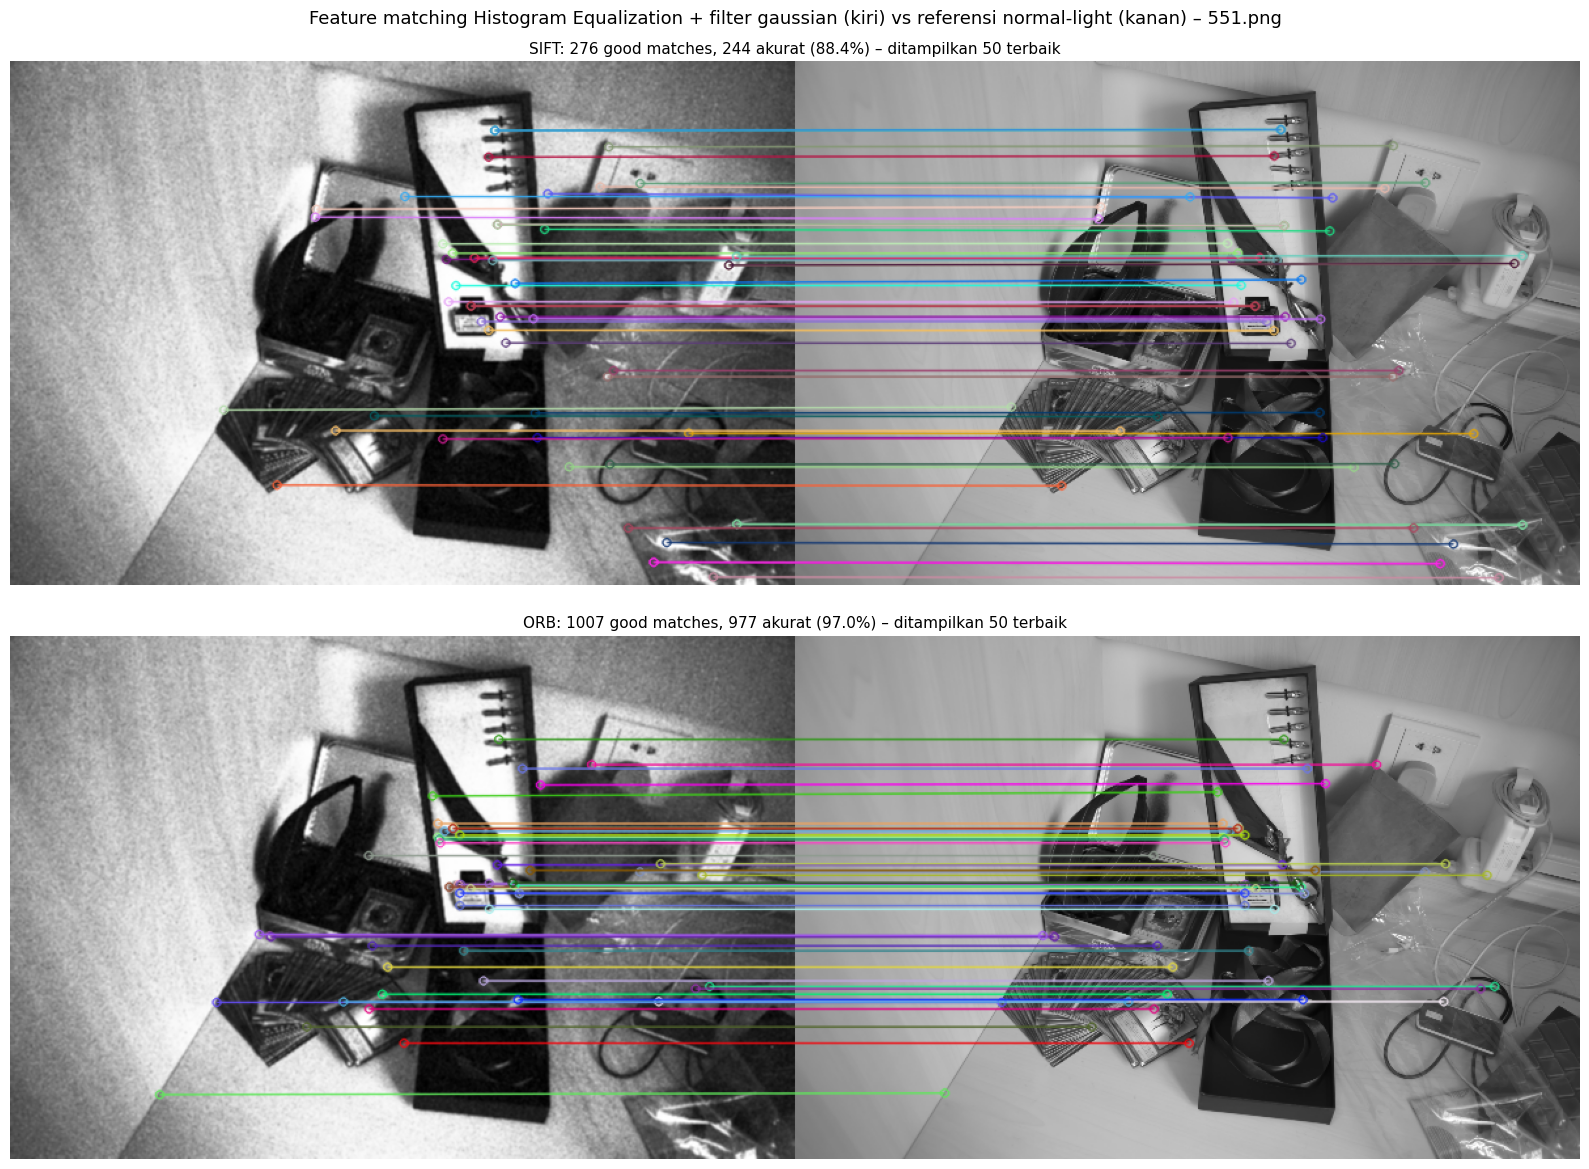

In [ ]:
# 4.7 Visualisasi matching SIFT vs ORB (sampel citra pertama, metode dengan PSNR terbaik di Section 3)
idx = 0
method_show = best   # metode dengan PSNR rata-rata tertinggi dari Section 3
N_SHOW = 50          # tampilkan 50 match terbaik agar gambar tidak terlalu padat

fig, axes = plt.subplots(2, 1, figsize=(16, 12))
for row, algo in enumerate(EXTRACTORS):
    kp1, _ = features[(algo, method_show, idx)]
    kp2, _ = ref_features[(algo, idx)]
    good = sorted(matches_cache[(algo, method_show, idx)], key=lambda m: m.distance)
    vis = cv2.drawMatches(filtered_images[method_show][idx], kp1, ref_gray[idx], kp2, good[:N_SHOW], None,
                          flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    n_acc = match_accuracy(kp1, kp2, good)
    axes[row].imshow(vis)
    axes[row].set_title(f"{algo}: {len(good)} good matches, {n_acc} akurat "
                        f"({100 * n_acc / len(good) if good else 0:.1f}%) – ditampilkan {min(N_SHOW, len(good))} terbaik",
                        fontsize=11)
    axes[row].axis("off")

plt.suptitle(f"Feature matching {method_show} + filter {FILTER_METHOD} (kiri) vs referensi normal-light (kanan) – {names[idx]}",
             fontsize=13)
plt.tight_layout()
plt.show()

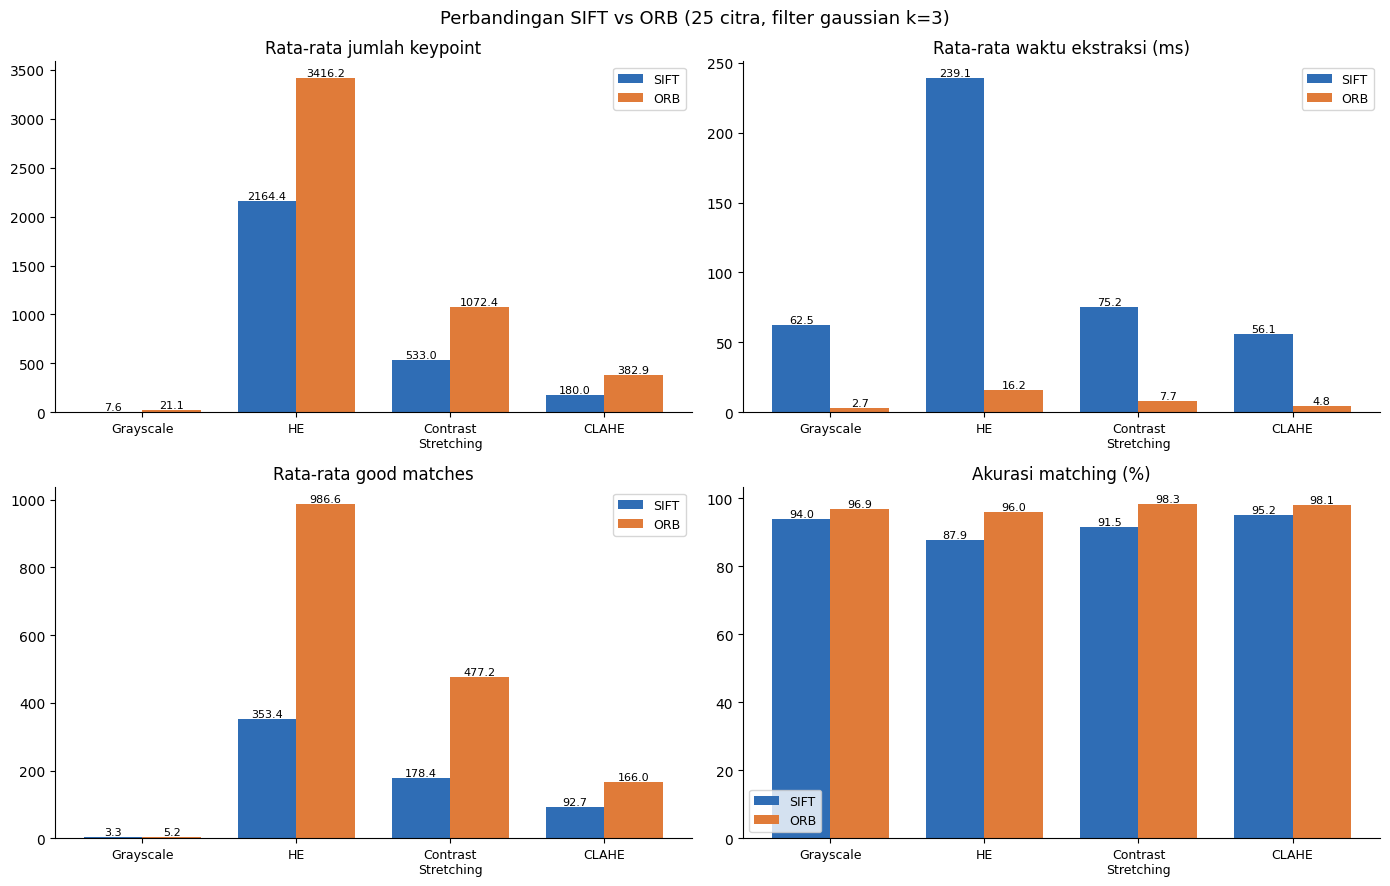

In [ ]:
# 4.8 Grafik perbandingan SIFT vs ORB per metode
metrics = [("Keypoint", feat_avg, "Rata-rata jumlah keypoint"),
           ("Waktu (ms)", feat_avg, "Rata-rata waktu ekstraksi (ms)"),
           ("Good matches", match_avg, "Rata-rata good matches"),
           ("Akurasi (%)", match_avg, "Akurasi matching (%)")]
x = np.arange(len(order))
w = 0.38
xlabels = [m.replace(" (tanpa enhancement)", "").replace("Histogram Equalization", "HE")
            .replace("Contrast Stretching", "Contrast\nStretching") for m in order]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (prefix, table, title) in zip(axes.ravel(), metrics):
    b1 = ax.bar(x - w/2, table[f"{prefix} SIFT"], w, label="SIFT", color="#2f6db5")
    b2 = ax.bar(x + w/2, table[f"{prefix} ORB"], w, label="ORB", color="#e07b39")
    ax.bar_label(b1, fmt="%.1f", fontsize=8)
    ax.bar_label(b2, fmt="%.1f", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, fontsize=9)
    ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=9)

plt.suptitle(f"Perbandingan SIFT vs ORB ({len(names)} citra, filter {FILTER_METHOD} k={KSIZE})", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# 4.9 Ringkasan keseluruhan SIFT vs ORB (rata-rata semua metode dan citra)
summary = pd.DataFrame({
    "Rata-rata keypoint/citra": df_feat.groupby("algoritma")["jumlah_keypoint"].mean(),
    "Rata-rata waktu ekstraksi (ms)": df_feat.groupby("algoritma")["waktu_ekstraksi_ms"].mean(),
    "Waktu per 1000 keypoint (ms)": df_feat.groupby("algoritma").apply(
        lambda d: 1000 * d["waktu_ekstraksi_ms"].sum() / max(d["jumlah_keypoint"].sum(), 1)),
    "Rata-rata good matches": df_match.groupby("algoritma")["good_matches"].mean(),
    "Akurasi matching (%)": 100 * df_match.groupby("algoritma")["match_akurat"].sum()
                            / df_match.groupby("algoritma")["good_matches"].sum().replace(0, np.nan),
    "Rata-rata waktu matching (ms)": df_match.groupby("algoritma")["waktu_matching_ms"].mean(),
}).reindex(["SIFT", "ORB"]).round(2)

print("RINGKASAN PERBANDINGAN SIFT vs ORB")
display(summary)

faster = summary["Rata-rata waktu ekstraksi (ms)"].idxmin()
ratio_speed = summary["Rata-rata waktu ekstraksi (ms)"].max() / summary["Rata-rata waktu ekstraksi (ms)"].min()
print(f"- Ekstraksi lebih cepat : {faster} (sekitar {ratio_speed:.1f}x lebih cepat)")
print(f"- Keypoint lebih banyak : {summary['Rata-rata keypoint/citra'].idxmax()}")
print(f"- Akurasi matching lebih tinggi : {summary['Akurasi matching (%)'].idxmax()}")

RINGKASAN PERBANDINGAN SIFT vs ORB


/tmp/ipykernel_849/2187856944.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  "Waktu per 1000 keypoint (ms)": df_feat.groupby("algoritma").apply(


,Rata-rata keypoint/citra,Rata-rata waktu ekstraksi (ms),Waktu per 1000 keypoint (ms),Rata-rata good matches,Akurasi matching (%),Rata-rata waktu matching (ms)
algoritma,,,,,,
SIFT,721.25,108.23,150.06,156.96,90.03,24.97
ORB,1223.15,7.85,6.42,408.74,96.91,94.41


- Ekstraksi lebih cepat : ORB (sekitar 13.8x lebih cepat)
- Keypoint lebih banyak : ORB
- Akurasi matching lebih tinggi : ORB
